In [ ]:
pip install shap

In [ ]:
import joblib
import pandas as pd
import shap

# Load model
best_model = joblib.load("best_model.pkl")

# Load data
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")

In [ ]:
#create Explainer
explainer = shap.TreeExplainer(best_model)

In [ ]:
#compute shap values
shap_values = explainer.shap_values(X_test)

# For fraud (class = 1)
shap_values_class1 = shap_values[1]

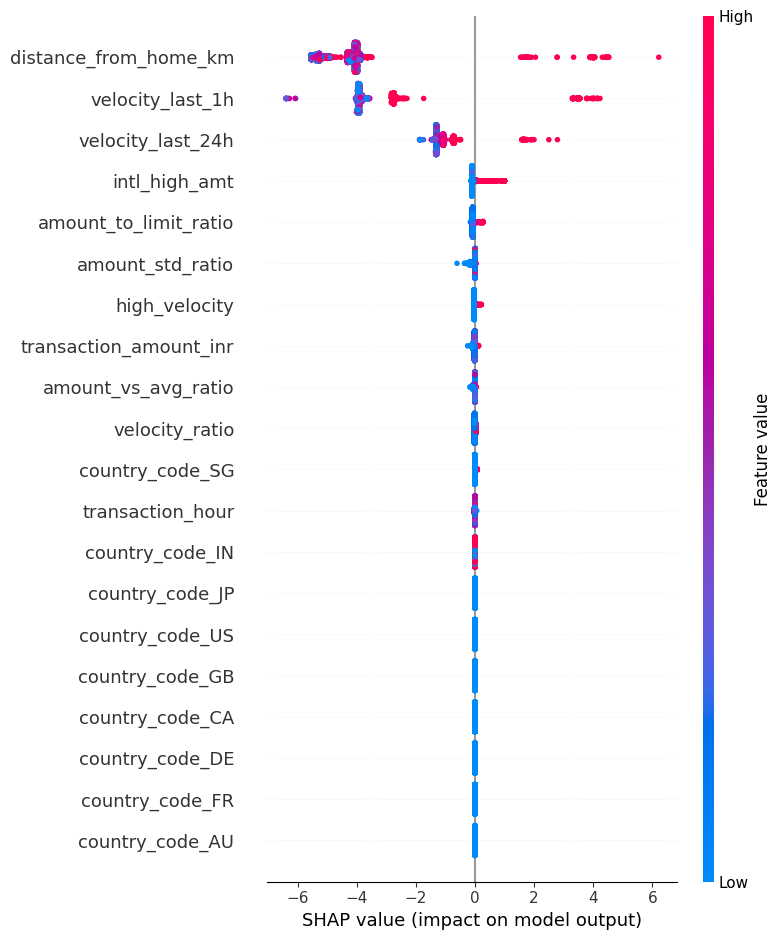

In [ ]:
#Summary plot
shap.summary_plot(shap_values, X_test)

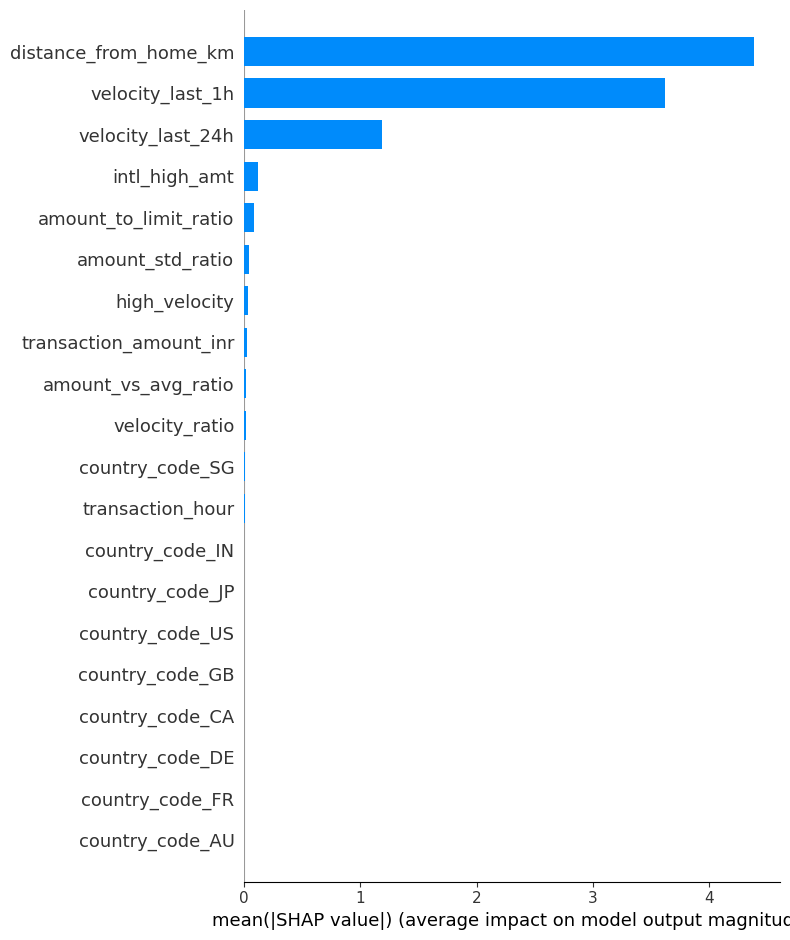

In [ ]:
#bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
import numpy as np

# Select a transaction index (fraud case preferred)
index = 10

# Get SHAP values for that transaction
shap_values_single = explainer.shap_values(X_test.iloc[[index]])

# Handle both old and new SHAP formats
if isinstance(shap_values_single, list):
    shap_values_single = shap_values_single[1]  # fraud class

shap_values_single = shap_values_single[0]

# Get feature names
features = X_test.columns

# Pair feature names with SHAP values
feature_impact = list(zip(features, shap_values_single))

# Sort by absolute impact
feature_impact_sorted = sorted(feature_impact, key=lambda x: abs(x[1]), reverse=True)

# Pick top 3 important features
top_features = feature_impact_sorted[:3]

# Generate explanation
explanation = "This transaction was flagged as suspicious due to the following factors:\n"

for feature, value in top_features:
    if value > 0:
        explanation += f"- {feature} increased the likelihood of fraud.\n"
    else:
        explanation += f"- {feature} reduced the likelihood, but was still influential.\n"

print(explanation)

This transaction was flagged as suspicious due to the following factors:
- distance_from_home_km reduced the likelihood, but was still influential.
- velocity_last_1h reduced the likelihood, but was still influential.
- velocity_last_24h reduced the likelihood, but was still influential.

